1. Cual es el TOP10 de juegos más jugados?
2. Cuál es el género de videojuegos más vendido?
3. Qué géneros tienen mejores reviews de media?
4. Cuánto ha ganado el desarrollador que más juegos ha vendido?
5. Cómo afecta a las reviews que un juego sea Early Access?
6. Cuál es el desarrollador (o desarrolladores) que más tipos de juego y cantidad ha desarrollado?
7. En qué mes, desde que tenemos datos, se han publicado más juegos?
8. Cuántas horas se juega de media a cada tipo de juego mensualmente?
9. Los juegos Free to Play tienen mejores o peores reviews?
10. Cómo ha evolucionado el número de achievements (trofeos) por juego?

# Importando librerías

In [39]:
import pandas as pd
import urllib.request as Req
from zipfile import ZipFile
import numpy as np

# Consiguiendo los datos

### Conseguir link

In [ ]:
url = "link de descarga del archivo" # Solo si su procedencia es de internet

### Descargar el archivo

In [ ]:
Req.urlretrieve(url, "Ruta/YElNombreDelArchivo.zip") # Asi se descarga el archivo si se tuviera el link de internet

### Descomprimir el archivo

In [2]:
steam_zip = ZipFile("SteamDataset-220424-201858.zip")

In [3]:
steam_zip.filelist

[<ZipInfo filename='steam.csv' compress_type=deflate external_attr=0x20 file_size=3425223 compress_size=979195>]

In [4]:
archivo = steam_zip.open('steam.csv')

### Construir DataFrame

In [5]:
df = pd.read_csv(archivo, index_col=[0])

In [6]:
df.head()

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
0,Counter-Strike,2000-11-01,Valve,0,124534,3339,17612,7.19€,15000000.0,True,False,False,False,False,False,False,False
1,Team Fortress Classic,1999-04-01,Valve,0,3318,633,277,3.99€,7500000.0,True,False,False,False,False,False,False,False
2,Day of Defeat,2003-05-01,Valve,0,3416,398,187,3.99€,7500000.0,True,False,False,False,False,False,False,False
3,Deathmatch Classic,2001-06-01,Valve,0,1273,267,258,3.99€,7500000.0,True,False,False,False,False,False,False,False
4,Half-Life: Opposing Force,1999-11-01,Gearbox Software,0,5250,288,624,3.99€,7500000.0,True,False,False,False,False,False,False,False


# Limpieza y manipulación de datos

## Quitar datos duplicados o irrelevantes

In [7]:
df.duplicated().any() # Vemos que hay al menos una fila duplicada

np.True_

In [8]:
duplicados = df.duplicated()
duplicados

0        False
1        False
2        False
3        False
4        False
         ...  
27098     True
27099     True
27100     True
27101     True
27102     True
Length: 27103, dtype: bool

In [9]:
duplicados_todos = df.duplicated(keep=False) # True todas las filas que estén duplicadas (entre si)
duplicados_todos

0        False
1        False
2        False
3        False
4        False
         ...  
27098     True
27099     True
27100     True
27101     True
27102     True
Length: 27103, dtype: bool

In [10]:
filas_duplicadas = df[df.duplicated(keep=False)]
filas_duplicadas

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
2879,Ampu-Tea,2014-05-30,ProjectorGames,11,1285,754,202,3.99€,350000.0,False,True,True,True,False,False,False,False
4307,Starlaxis Supernova Edition,2015-02-11,Spiderwork Games,15,32,19,146,6.19€,10000.0,True,False,False,False,True,False,False,False
5525,Dungeon Hero,2015-07-07,Grzegorz Slazinski,0,50,50,0,4.99€,35000.0,True,True,True,False,False,False,False,False
6852,GabeN: The Final Decision,2015-09-21,Alex Zhang,13,432,270,243,0.79€,150000.0,False,False,True,False,False,False,False,False
8504,MiniGolf Mania,2016-03-25,Road Turtle Games,0,36,16,0,0.0€,10000.0,False,False,False,False,False,False,False,False
9704,EARTH'S DAWN,2016-12-07,oneoreight,20,110,24,381,24.99€,10000.0,True,False,False,False,False,False,False,False
9947,SoulHunt,2016-12-23,WinterCell Studios,18,56,19,0,5.99€,10000.0,True,False,False,False,False,False,False,True
10173,Party Panic,2017-08-07,Everglow Interactive Inc.,28,619,226,84,12.99€,75000.0,True,False,False,False,False,False,False,False
10338,Temple of the Apsara,2016-09-06,Attraction Studios,0,37,11,0,1.59€,10000.0,False,True,False,False,False,False,False,False
12020,The Dungeon of Destiny,2018-03-03,LEVER Software,0,14,20,285,3.19€,10000.0,False,False,True,False,False,False,False,True


In [11]:
filas_duplicadas.shape[0] # El número de filas involucradas en el duplicado

56

In [12]:
filas_duplicadas.sort_values(by=df.columns.tolist())

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
2879,Ampu-Tea,2014-05-30,ProjectorGames,11,1285,754,202,3.99€,350000.0,False,True,True,True,False,False,False,False
27078,Ampu-Tea,2014-05-30,ProjectorGames,11,1285,754,202,3.99€,350000.0,False,True,True,True,False,False,False,False
13853,Blastercell,2017-05-10,Robot Games,14,9,5,265,3.99€,35000.0,True,False,False,False,False,False,False,False
27079,Blastercell,2017-05-10,Robot Games,14,9,5,265,3.99€,35000.0,True,False,False,False,False,False,False,False
19542,Champ Against Chumps Upgrade Edition,2018-04-20,MisterTtocS,22,2,0,0,1.69€,10000.0,False,False,False,False,False,False,False,False
27094,Champ Against Chumps Upgrade Edition,2018-04-20,MisterTtocS,22,2,0,0,1.69€,10000.0,False,False,False,False,False,False,False,False
25545,Cotrio,2019-01-22,Bartosz Bialek,6,3,0,0,1.69€,10000.0,False,False,False,False,True,False,False,False
27082,Cotrio,2019-01-22,Bartosz Bialek,6,3,0,0,1.69€,10000.0,False,False,False,False,True,False,False,False
5525,Dungeon Hero,2015-07-07,Grzegorz Slazinski,0,50,50,0,4.99€,35000.0,True,True,True,False,False,False,False,False
27086,Dungeon Hero,2015-07-07,Grzegorz Slazinski,0,50,50,0,4.99€,35000.0,True,True,True,False,False,False,False,False


In [13]:
df.duplicated().sum()

np.int64(28)

In [14]:
df = df[~df.duplicated(keep=False)] # Eliminamos todos los duplicados

In [15]:
df.duplicated().unique()

array([False])

In [16]:
df.columns

Index(['name', 'release_date', 'developer', 'achievements', 'positive_ratings',
       'negative_ratings', 'avg_hours_per_user', 'price', 'sells', 'action',
       'adventure', 'rpg', 'simulation', 'strategy', 'racing', 'free_to_play',
       'early_access'],
      dtype='object')

In [17]:
df.duplicated().sum() # Ya no hay filas completamente identicas en todas las columnas

np.int64(0)

In [18]:
df["name"].duplicated().sum() # Pero si hay duplicados con el mismo nombre

np.int64(42)

In [19]:
df.loc[df["name"].duplicated(), "name"].unique() # Lista de los nombres duplicados

array(['Dark Matter', 'Ultimate Arena', 'New York Bus Simulator', 'Taxi',
       'Mars 2030', 'Rumpus', 'Invasion', 'Alter Ego', 'Castles', 'Luna',
       'Slice&Dice', 'Killing Time', 'The Tower', 'Colony',
       'Beyond the Wall', 'Solitaire', 'Escape Room', 'Escape', 'Dodge',
       'Mystical', 'The Great Escape', 'Bounce', 'City Builder', 'RUSH',
       'Evolution', 'Alone', 'Scorch', 'The Mine', 'Ashes', 'Exodus',
       'Space Maze', 'Nightmare Simulator', 'Fireflies', 'Surge',
       "Santa's Workshop", 'Chaos Theory', 'Zombie Apocalypse', 'Cortex',
       'Hide and Seek', 'Experience', '2048'], dtype=object)

In [20]:
df["name"].value_counts()[lambda x: x > 1] # nombre repetidos y su cantidad

name
Dark Matter               3
Space Maze                2
2048                      2
Invasion                  2
Experience                2
The Great Escape          2
Alter Ego                 2
Beyond the Wall           2
Killing Time              2
Fireflies                 2
Scorch                    2
Santa's Workshop          2
Solitaire                 2
Surge                     2
Nightmare Simulator       2
New York Bus Simulator    2
The Mine                  2
Bounce                    2
Escape Room               2
Slice&Dice                2
The Tower                 2
Mystical                  2
Castles                   2
Evolution                 2
Chaos Theory              2
Dodge                     2
City Builder              2
Escape                    2
Luna                      2
Zombie Apocalypse         2
Alone                     2
Rumpus                    2
Colony                    2
RUSH                      2
Cortex                    2
Hide and Seek  

In [21]:
df[df["name"].duplicated(keep=False)].sort_values("name") # Como son de diferentes desarrolladores los vamos a conservar


,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
26587,2048,2019-02-21,Dexion Games,0,0,1,0,0.79€,10000.0,False,False,False,True,False,False,False,False
24723,2048,2018-10-31,Lucas Alexander Visual Arts;Nicolai Clemmensen...,15,4,0,0,4.49€,10000.0,False,False,False,False,True,False,False,False
22740,Alone,2018-06-21,Avasion,7,17,5,0,0.79€,10000.0,False,True,False,False,False,False,False,False
21554,Alone,2018-05-01,Killed Pixel Games,20,9,2,0,0.79€,10000.0,False,True,False,True,True,False,False,False
968,Alter Ego,2010-08-03,bitComposer Games,0,139,59,12,7.19€,35000.0,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16742,The Tower,2018-02-16,Headroom.one,0,7,5,0,5.19€,10000.0,False,True,False,False,False,False,False,False
6189,Ultimate Arena,2016-08-22,Triverske,20,715,159,280,3.99€,75000.0,False,False,False,True,False,False,False,False
7912,Ultimate Arena,2016-09-05,Kenneth Caselli;Gianmarco Rocco,1,123,100,0,13.99€,10000.0,True,False,False,False,False,False,False,False
13222,Zombie Apocalypse,2017-02-15,GameTop.com,0,27,17,10,0.0€,10000.0,True,False,False,False,False,False,False,False


In [22]:
df.duplicated(subset=["name", "developer"]).any()

np.True_

In [23]:
df.duplicated(subset=["name", "developer"]).sum()

np.int64(1)

In [24]:
df[df.duplicated(subset=["name", "developer"], keep=False)] # Optaré por quedarme con la fila con la fecha más reciente
# Suponiendo que se debe a que es una versión más reciente y actualizada

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
14679,Slice&Dice,2017-05-31,VRotein,17,5,1,0,6.99€,10000.0,False,False,False,False,False,False,False,False
16238,Slice&Dice,2017-08-04,VRotein,17,1,0,0,3.99€,10000.0,False,False,False,True,False,False,False,False


In [25]:
df = df.drop(index=14679)

In [26]:
df.duplicated(subset=["name", "developer"]).sum() # Asi comprobamos que eliminamos este valor duplicado

np.int64(0)

In [27]:
df.head()

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
0,Counter-Strike,2000-11-01,Valve,0,124534,3339,17612,7.19€,15000000.0,True,False,False,False,False,False,False,False
1,Team Fortress Classic,1999-04-01,Valve,0,3318,633,277,3.99€,7500000.0,True,False,False,False,False,False,False,False
2,Day of Defeat,2003-05-01,Valve,0,3416,398,187,3.99€,7500000.0,True,False,False,False,False,False,False,False
3,Deathmatch Classic,2001-06-01,Valve,0,1273,267,258,3.99€,7500000.0,True,False,False,False,False,False,False,False
4,Half-Life: Opposing Force,1999-11-01,Gearbox Software,0,5250,288,624,3.99€,7500000.0,True,False,False,False,False,False,False,False


## Arreglar errores estructurales

In [28]:
df.sample(15)

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
5918,Daemon Detective Gaiden,2015-08-14,Yal,53,11,2,0,6.99€,10000.0,True,True,False,False,False,False,False,False
23277,Ultimate War,2018-08-03,GamePowerEs,0,1,1,0,4.79€,10000.0,False,False,False,True,False,False,False,True
25380,Sakura MMO 2,2019-01-25,Winged Cloud,15,29,3,0,7.19€,10000.0,False,False,False,True,False,False,False,False
21774,Demon's Rise - War for the Deep,2018-04-29,Wave Light Games Inc.,0,42,6,0,5.19€,10000.0,True,False,True,False,True,False,False,False
13297,Mystery Tales: The Lost Hope Collector's Edition,2017-02-22,Domini Games,18,3,2,0,6.99€,10000.0,False,True,False,False,False,False,False,False
14758,BOXVR,2017-06-13,FitXR,0,443,58,157,14.99€,35000.0,True,False,False,False,False,False,False,True
7110,Roads of Rome 3,2015-10-19,Whiterra,0,12,3,0,2.79€,10000.0,False,True,False,True,True,False,False,False
4441,The Moment of Silence,2015-03-27,House of Tales,0,30,19,0,13.99€,10000.0,False,True,False,False,False,False,False,False
17985,The Monk and the Warrior. The Heart of the King.,2018-03-02,Paper Pirates,0,17,24,0,2.89€,10000.0,True,True,True,False,False,False,False,False
22217,"Snake, snake, snake!",2018-05-18,GrowFall Studios,5,11,4,0,1.69€,10000.0,True,False,False,False,False,False,False,False


In [29]:
df.head()

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
0,Counter-Strike,2000-11-01,Valve,0,124534,3339,17612,7.19€,15000000.0,True,False,False,False,False,False,False,False
1,Team Fortress Classic,1999-04-01,Valve,0,3318,633,277,3.99€,7500000.0,True,False,False,False,False,False,False,False
2,Day of Defeat,2003-05-01,Valve,0,3416,398,187,3.99€,7500000.0,True,False,False,False,False,False,False,False
3,Deathmatch Classic,2001-06-01,Valve,0,1273,267,258,3.99€,7500000.0,True,False,False,False,False,False,False,False
4,Half-Life: Opposing Force,1999-11-01,Gearbox Software,0,5250,288,624,3.99€,7500000.0,True,False,False,False,False,False,False,False


In [30]:
df.tail()

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
27070,Room of Pandora,2019-04-24,SHEN JIAWEI,7,3,0,0,2.09€,10000.0,False,True,False,False,False,False,False,False
27071,Cyber Gun,2019-04-23,Semyon Maximov,0,8,1,0,1.69€,10000.0,True,True,False,False,False,False,False,False
27072,Super Star Blast,2019-04-24,EntwicklerX,24,0,1,0,3.99€,10000.0,True,False,False,False,False,False,False,False
27073,New Yankee 7: Deer Hunters,2019-04-17,Yustas Game Studio,0,2,0,0,5.19€,10000.0,False,True,False,False,False,False,False,False
27074,Rune Lord,2019-04-24,Adept Studios GD,0,4,0,0,5.19€,10000.0,False,True,False,False,False,False,False,False


Verificamos que las columnas booleanas en verdad lo son

In [59]:
# Devuelve True si la columna es de tipo 'bool'
df['action'].dtype == 'bool'

True

In [62]:
df['adventure'].dtype == 'bool'

True

In [63]:
df['rpg'].dtype == 'bool'

True

In [64]:
df['simulation'].dtype == 'bool'

True

In [65]:
df['strategy'].dtype == 'bool'

True

In [66]:
df['racing'].dtype == 'bool'

True

In [67]:
df['free_to_play'].dtype == 'bool'

True

In [68]:
df['early_access'].dtype == 'bool'

True

### Definir errores
Notas de lo que se tiene que corregir:
- price tiene signo de euros
- sells a enteros

### _price tiene signo de euros_

In [31]:
valores = []
for i in df["price"].unique():
    valores.append(str(i).endswith("€"))

In [32]:
set(valores) # Comprobamos que todos los valores tienen este problema

{True}

In [33]:
# Hacemos que sobre cada string de la columna 
df["price"] = df["price"].str.replace("€", "").apply(float) # Quita el porcetaje y lo convierte en float

In [34]:
df["price"].dtype

dtype('float64')

In [35]:
df.tail()

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
27070,Room of Pandora,2019-04-24,SHEN JIAWEI,7,3,0,0,2.09,10000.0,False,True,False,False,False,False,False,False
27071,Cyber Gun,2019-04-23,Semyon Maximov,0,8,1,0,1.69,10000.0,True,True,False,False,False,False,False,False
27072,Super Star Blast,2019-04-24,EntwicklerX,24,0,1,0,3.99,10000.0,True,False,False,False,False,False,False,False
27073,New Yankee 7: Deer Hunters,2019-04-17,Yustas Game Studio,0,2,0,0,5.19,10000.0,False,True,False,False,False,False,False,False
27074,Rune Lord,2019-04-24,Adept Studios GD,0,4,0,0,5.19,10000.0,False,True,False,False,False,False,False,False


### _sells a enteros_

In [45]:
valores = []
for i in df["sells"]:
    valores.append(str(i)[-1])

In [46]:
set(valores)

{'0'}

In [48]:
df["sells"] = df["sells"].astype(int)

In [55]:
df.sample()

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
10013,Super Markup Man,2016-08-16,Roppy Chop Studios,8,47,9,0,2.89,10000,False,False,False,False,False,False,False,False


## Filtrar outliers 

Valores atipicos

In [69]:
df.describe()

,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells
count,27046.000000,2.704600e+04,27046.000000,27046.000000,27046.000000,2.704600e+04
mean,45.271833,1.001518e+03,211.199882,149.906197,6.079525,1.342015e+05
std,352.854167,1.899888e+04,4287.229314,1828.011418,7.876981,1.328794e+06
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+04
25%,0.000000,6.000000e+00,2.000000,0.000000,1.690000,1.000000e+04
50%,7.000000,2.400000e+01,9.000000,0.000000,3.990000,1.000000e+04
75%,23.000000,1.260000e+02,42.000000,0.000000,7.190000,3.500000e+04
max,9821.000000,2.644404e+06,487076.000000,190625.000000,421.990000,1.500000e+08


## Lidiar con NANs

Valores vacios

In [71]:
df.isna() # Por cada valor nos devuelve si es NaN o no (es una mascara booleana)

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27070,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27071,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27072,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
27073,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [72]:
df.isna().any() # Nos indica si en nuestras columnas hay almenos un dato que sea valor NaN

name                  False
release_date          False
developer              True
achievements          False
positive_ratings      False
negative_ratings      False
avg_hours_per_user    False
price                 False
sells                 False
action                False
adventure             False
rpg                   False
simulation            False
strategy              False
racing                False
free_to_play          False
early_access          False
dtype: bool

In [73]:
# Vamos a revisar la columna de developer
df[df["developer"].isna()]

,name,release_date,developer,achievements,positive_ratings,negative_ratings,avg_hours_per_user,price,sells,action,adventure,rpg,simulation,strategy,racing,free_to_play,early_access
23071,The Battle Of Ages,2018-09-07,NaN,0,2,1,0,3.99,10000,True,False,True,False,False,False,False,True


In [75]:
len(df[df["developer"].isna()]) # solo es un valor que nos falta

1

Investigando por internet encuentro que elnombre del desarrollador es: DR Studios

In [76]:
df["developer"].fillna("DR Studios", inplace= True)

/tmp/ipykernel_3518/34864336.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["developer"].fillna("DR Studios", inplace= True)


In [ ]:
df.isna().any() # corroboramos que ya no tenemos NaN

name                  False
release_date          False
developer             False
achievements          False
positive_ratings      False
negative_ratings      False
avg_hours_per_user    False
price                 False
sells                 False
action                False
adventure             False
rpg                   False
simulation            False
strategy              False
racing                False
free_to_play          False
early_access          False
dtype: bool

In [83]:
# Filtramos filas que contienen 'studios' (sin importar mayúsculas)
# .str.contains es ideal para buscar sub-cadenas
mask = df["developer"].str.contains("dr studios", case=False, na=False)
variantes = df.loc[mask, "developer"].unique()

print(variantes)

['DR Studios']


## Validar nuestros datos

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27046 entries, 0 to 27074
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                27046 non-null  object 
 1   release_date        27046 non-null  object 
 2   developer           27046 non-null  object 
 3   achievements        27046 non-null  int64  
 4   positive_ratings    27046 non-null  int64  
 5   negative_ratings    27046 non-null  int64  
 6   avg_hours_per_user  27046 non-null  int64  
 7   price               27046 non-null  float64
 8   sells               27046 non-null  int64  
 9   action              27046 non-null  bool   
 10  adventure           27046 non-null  bool   
 11  rpg                 27046 non-null  bool   
 12  simulation          27046 non-null  bool   
 13  strategy            27046 non-null  bool   
 14  racing              27046 non-null  bool   
 15  free_to_play        27046 non-null  bool   
 16  early_acc

# EDA (analisis de datos exploratorio)

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

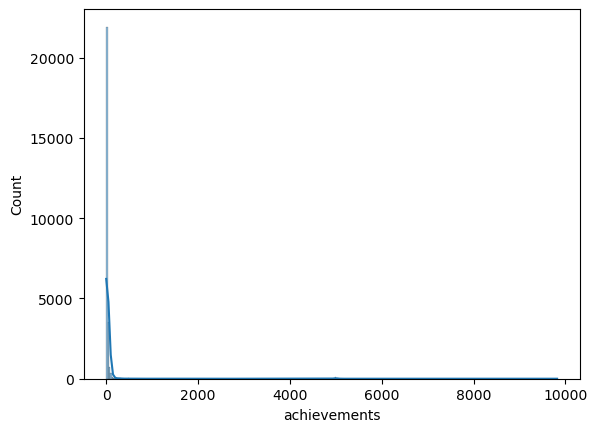

In [92]:
# Histograma para ver la distribución
sns.histplot(df['achievements'], kde=True)
plt.show()

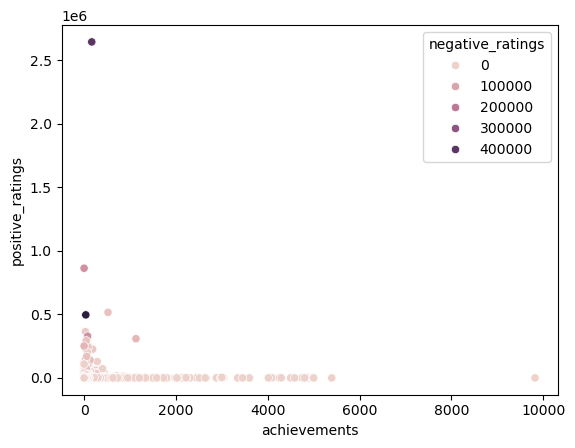

In [97]:
sns.scatterplot(data=df, x='achievements', y='positive_ratings', hue='negative_ratings')
plt.show()

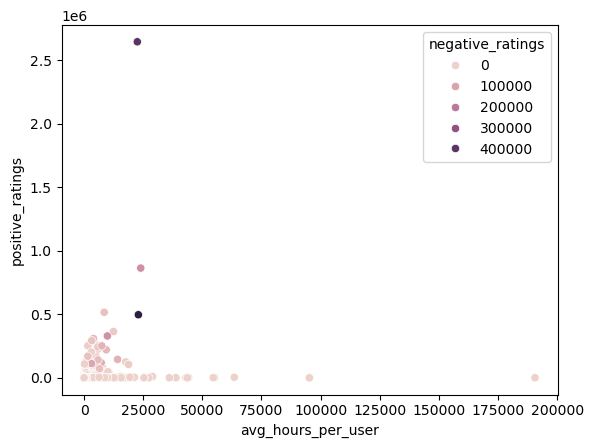

In [98]:
sns.scatterplot(data=df, x='avg_hours_per_user', y='positive_ratings', hue='negative_ratings')
plt.show()

In [ ]:
#!pip install ydata-profiling

In [104]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Reporte de EDA")
profile.to_file("mi_analisis.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:01<00:00, 15.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Cual es el TOP10 de juegos más jugados?

## Cuál es el género de videojuegos más vendido?

## Qué géneros tienen mejores reviews de media?

## Cuánto ha ganado el desarrollador que más juegos ha vendido?

## Cómo afecta a las reviews que un juego sea Early Access?

## Cuál es el desarrollador (o desarrolladores) que más tipos de juego y cantidad ha desarrollado?

## En qué mes, desde que tenemos datos, se han publicado más juegos?

## Cuántas horas se juega de media a cada tipo de juego mensualmente?

## Los juegos Free to Play tienen mejores o peores reviews?

## Cómo ha evolucionado el número de achievements (trofeos) por juego?

## Bonus! Si tienes curiosidad, y quieres contestar más preguntas, puedes resolverlas aquí mismo!